<a href="https://colab.research.google.com/github/camilacruz-cs/python-para-inovacao-civica/blob/main/semana_3_CEAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Acessando os dados da CEAP via API

In [1]:
%pip install requests

In [2]:
import requests

In [3]:
r = requests.get("http://www.camara.leg.br/cotas/Ano-2019.csv.zip")

In [4]:
file = open("Ano-2019.csv.zip", "wb")
file.write(r.content)
file.close()

In [5]:
#O arquivo que foi criado está zipado, então é importante 'deszipar'

from zipfile import ZipFile

In [6]:
zip_file = ZipFile("Ano-2019.csv.zip", "r")


In [7]:
#Namelist ele lista todos os arquivos que estão dentro do arquivo zipado.

zip_file.namelist()

['Ano-2019.csv']

In [8]:
zip_file.extract(member="Ano-2019.csv", path="reembolso-2019")

'reembolso-2019/Ano-2019.csv'

In [9]:
zip_file.close()

### Lendo os dados da CEAP com Pandas

In [10]:
import pandas as pd

In [11]:
reembolso_2019 = pd.read_csv('reembolso-2019/Ano-2019.csv', delimiter=";")

In [12]:
reembolso_2019.columns

Index(['txNomeParlamentar', 'cpf', 'ideCadastro', 'nuCarteiraParlamentar',
       'nuLegislatura', 'sgUF', 'sgPartido', 'codLegislatura', 'numSubCota',
       'txtDescricao', 'numEspecificacaoSubCota', 'txtDescricaoEspecificacao',
       'txtFornecedor', 'txtCNPJCPF', 'txtNumero', 'indTipoDocumento',
       'datEmissao', 'vlrDocumento', 'vlrGlosa', 'vlrLiquido', 'numMes',
       'numAno', 'numParcela', 'txtPassageiro', 'txtTrecho', 'numLote',
       'numRessarcimento', 'datPagamentoRestituicao', 'vlrRestituicao',
       'nuDeputadoId', 'ideDocumento', 'urlDocumento'],
      dtype='object')

In [13]:
reembolso_2019.head()

,txNomeParlamentar,cpf,ideCadastro,nuCarteiraParlamentar,nuLegislatura,sgUF,sgPartido,codLegislatura,numSubCota,txtDescricao,...,numParcela,txtPassageiro,txtTrecho,numLote,numRessarcimento,datPagamentoRestituicao,vlrRestituicao,nuDeputadoId,ideDocumento,urlDocumento
0,LID.GOV-CD,NaN,NaN,NaN,2015,NaN,NaN,55,13,FORNECIMENTO DE ALIMENTAÇÃO DO PARLAMENTAR,...,0,NaN,NaN,1554246,NaN,NaN,NaN,2812,6738121,https://www.camara.leg.br/cota-parlamentar/not...
1,LID.GOV-CD,NaN,NaN,NaN,2019,NaN,NaN,56,13,FORNECIMENTO DE ALIMENTAÇÃO DO PARLAMENTAR,...,0,NaN,NaN,1570078,NaN,NaN,NaN,2812,6769606,https://www.camara.leg.br/cota-parlamentar/not...
2,LID.GOV-CD,NaN,NaN,NaN,2019,NaN,NaN,56,13,FORNECIMENTO DE ALIMENTAÇÃO DO PARLAMENTAR,...,0,NaN,NaN,1570503,NaN,NaN,NaN,2812,6771099,https://www.camara.leg.br/cota-parlamentar/not...
3,LID.GOV-CD,NaN,NaN,NaN,2019,NaN,NaN,56,13,FORNECIMENTO DE ALIMENTAÇÃO DO PARLAMENTAR,...,0,NaN,NaN,1579375,NaN,NaN,NaN,2812,6793690,https://www.camara.leg.br/cota-parlamentar/not...
4,LID.GOV-CD,NaN,NaN,NaN,2019,NaN,NaN,56,13,FORNECIMENTO DE ALIMENTAÇÃO DO PARLAMENTAR,...,0,NaN,NaN,1590980,NaN,NaN,NaN,2812,6821674,https://www.camara.leg.br/cota-parlamentar/not...


### Vamos refletir

Procure entender quais os tipos de dados formam sua base. São dados numéricos? São textos? São palavras usadas para categorizar ou classificar?
Agora que você sabe mais informações sobre os dados, comece a formular perguntas.
Se você sabe que uma das variáveis é numérica, se pergunte por exemplo como ela se distribui.

In [14]:
#Quem são os deputados que aparecem no dataframe?

reembolso_2019[['txNomeParlamentar','sgUF', 'sgPartido']]

,txNomeParlamentar,sgUF,sgPartido
0,LID.GOV-CD,NaN,NaN
1,LID.GOV-CD,NaN,NaN
2,LID.GOV-CD,NaN,NaN
3,LID.GOV-CD,NaN,NaN
4,LID.GOV-CD,NaN,NaN
...,...,...,...
289453,Dr. Gonçalo,MA,REPUBLICANOS
289454,Marcão Gomes,RJ,PL
289455,Marcão Gomes,RJ,PL
289456,Marcão Gomes,RJ,PL


### Analisando os dados da CEAP



### frequência

In [15]:
reembolso_2019['sgPartido'].value_counts()

PT               40696
PL               36884
PP               30527
UNIÃO            27029
PSD              25996
REPUBLICANOS     21923
MDB              20635
PSB              14493
PSDB             13540
PDT              10854
PODE              4972
PSOL              4787
PCdoB             3947
PSC               3935
SOLIDARIEDADE     3893
AVANTE            3745
CIDADANIA         3517
NOVO              3131
PROS              2836
PATRIOTA          2399
PV                2394
PTB               2153
DEM               1154
PR                1118
REDE               789
PRB                531
PPS                225
PATRI              154
PHS                139
PSL                137
PPL                 20
Name: sgPartido, dtype: int64

In [16]:
reembolso_2019['txtDescricaoEspecificacao'].value_counts()

Veículos Automotores    64165
Sem especificações        322
Aeronaves                 252
Embarcações                26
Name: txtDescricaoEspecificacao, dtype: int64

In [18]:
reembolso_2019['txtFornecedor'].value_counts()

Cia Aérea - GOL                           37225
Cia Aérea - TAM                           32633
Cia Aérea - AZUL                           8954
CELULAR FUNCIONAL                          6650
CASCOL COMBUSTIVEIS PARA VEICULOS LTDA     6532
                                          ...  
K. D. DA SILVA GOES                           1
KELLY QUEIROZ DA SILVA                        1
T P S FRANCO ME                               1
THIAGO CARLOS VON SCHARTEN                    1
CARRY SERVIÇOS E LOCAÇÕES                     1
Name: txtFornecedor, Length: 22393, dtype: int64

### estatística

In [19]:
reembolso_2019['vlrGlosa'].mean()

3.5318252734420885

<Axes: >

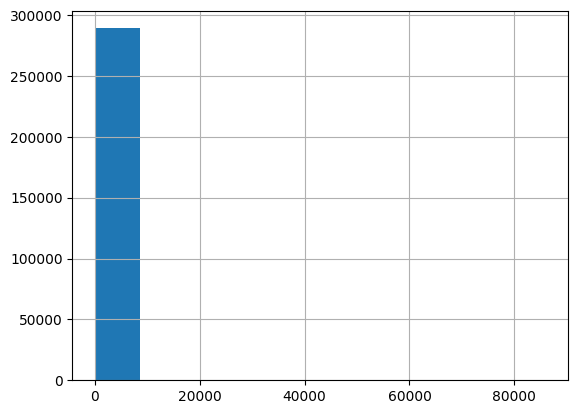

In [41]:
reembolso_2019['vlrGlosa'].hist()

In [20]:
#vlrLiquido representa o valor líquido do documento fiscal debitado
reembolso_2019['vlrLiquido'].min()

-6605.57

In [21]:
reembolso_2019['vlrLiquido'].max()

145140.0

In [22]:
reembolso_2019['vlrLiquido'].mean()

730.2184960857879

In [23]:
reembolso_2019['vlrLiquido'].describe()

count    289458.000000
mean        730.218496
std        2083.636663
min       -6605.570000
25%          50.000000
50%         191.850000
75%         715.750000
max      145140.000000
Name: vlrLiquido, dtype: float64

<Axes: >

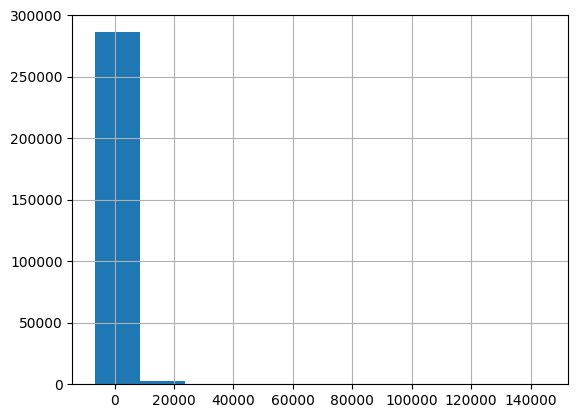

In [24]:
reembolso_2019['vlrLiquido'].hist()

<Axes: >

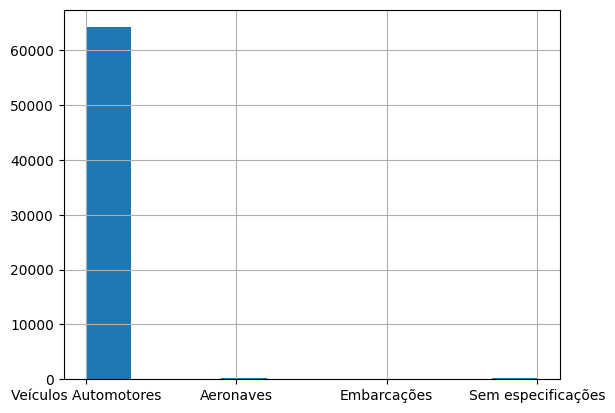

In [25]:
reembolso_2019['txtDescricaoEspecificacao'].hist()

### filtrando os dados

In [26]:
#Quem foi o parlamentar com maior valor líquido?

#Colunas necessárias: vlrLiquido e txNomeParlamentar

reembolso_2019[['vlrLiquido', 'txNomeParlamentar']].max()

vlrLiquido                 145140.0
txNomeParlamentar    Áurea Carolina
dtype: object

In [27]:
#Quem foram os parlamentares que tiveram o valor líquido acima de R$100.00?

In [28]:
# Filtrar os registros com valor líquido maior que 100.00
result = reembolso_2019[reembolso_2019['vlrLiquido'] > 100.00]

# Selecionar apenas as colunas 'vlrLiquido' e 'txNomeParlamentar'
result = result[['vlrLiquido', 'txNomeParlamentar']]

print(result)

        vlrLiquido txNomeParlamentar
0           111.30        LID.GOV-CD
1           117.19        LID.GOV-CD
2           120.15        LID.GOV-CD
3           151.18        LID.GOV-CD
4           119.90        LID.GOV-CD
...            ...               ...
289452     1925.79       Dr. Gonçalo
289453     1930.57       Dr. Gonçalo
289454      233.00      Marcão Gomes
289455     1890.66      Marcão Gomes
289457     1516.00      Marcão Gomes

[182884 rows x 2 columns]


### agrupamentos

In [29]:
#Qual o valor líquido gasto por parlamentar?

reembolso_2019[['vlrLiquido', 'txNomeParlamentar']].value_counts()

vlrLiquido  txNomeParlamentar         
2.40        Dimas Fabiano                 510
5.30        Júlio Delgado                 349
2.90        Professora Dayane Pimentel    275
5.30        Subtenente Gonzaga            222
5.80        Glauber Braga                 219
                                         ... 
132.74      Junio Amaral                    1
            Sanderson                       1
132.75      Benedita da Silva               1
132.76      Fernando Coelho Filho           1
145140.00   Weliton Prado                   1
Length: 196722, dtype: int64

In [30]:
# Calcular a soma do valor líquido
total_valor_liquido = reembolso_2019[['vlrLiquido', 'txNomeParlamentar']].sum()

# Exibir o total do valor líquido
print("Total do Valor Líquido:", total_valor_liquido)

Total do Valor Líquido: vlrLiquido                                                211367585.44
txNomeParlamentar    LID.GOV-CDLID.GOV-CDLID.GOV-CDLID.GOV-CDLID.GO...
dtype: object


In [34]:
#Por partido

grouped = reembolso_2019.groupby('sgPartido')
valor_liquido_parlamentar = grouped['vlrLiquido'].sum()
print(valor_liquido_parlamentar)

sgPartido
AVANTE            2147127.07
CIDADANIA         2030930.86
DEM               1166893.17
MDB              16254771.57
NOVO               843344.28
PATRI              161737.83
PATRIOTA          1918733.70
PCdoB             3662177.00
PDT               8152882.98
PHS                180055.49
PL               27034279.18
PODE              3706514.95
PP               22602979.99
PPL                 44925.75
PPS                218419.43
PR                1218771.70
PRB                621097.18
PROS              2806243.81
PSB               9181200.19
PSC               3254978.08
PSD              18624192.56
PSDB              9702029.03
PSL                150098.12
PSOL              3170204.95
PT               24590577.81
PTB               2142506.05
PV                1792453.29
REDE               721414.21
REPUBLICANOS     18650055.21
SOLIDARIEDADE     3531750.41
UNIÃO            20163574.05
Name: vlrLiquido, dtype: float64


In [36]:
agrup = reembolso_2019.groupby('sgUF')
agrup_estado =  agrup['vlrLiquido'].sum()
print(agrup_estado)

sgUF
AC     4130683.64
AL     4099385.88
AM     3960143.55
AP     4094046.88
BA    17430621.46
CE    10510221.37
DF     1795185.16
ES     3647082.75
GO     5899839.64
MA     8198348.85
MG    19526675.12
MS     3052895.87
MT     3086052.93
PA     8026741.86
PB     5505420.95
PE    10989237.34
PI     4590257.09
PR    12413012.86
RJ    17856044.25
RN     3600755.19
RO     3102359.61
RR     4115517.99
RS    12470844.49
SC     5463401.04
SE     3687619.60
SP    25646452.04
TO     3548072.49
Name: vlrLiquido, dtype: float64


In [37]:
#Por fornecedor

agrup_fornecedor = reembolso_2019.groupby('txtFornecedor')
agrup_fornecedor_valor = agrup_fornecedor['vlrLiquido'].sum()
print(agrup_fornecedor_valor)

txtFornecedor
"LUPA ALIMENTOS                                         106.70
"TRES MOSQUETEIROS RESTAURANTE, CHOPERIA E PIZZARI       59.90
''AUTO POSTO SOLAR DAS TERRAS LTDA''                   1388.42
''IMOBILIARIA ALTA AVENIDA LTDA                       12670.20
'Autopista Fernão Dias                                  844.80
                                                        ...   
Águas de Pará de Minas                                   51.62
ÂNCORA TÁXI - Praça XV                                  192.00
ÂNGELA MARIA LINS PESSOA DE SOUZA                     12275.50
ÉMP BRAS DE CORREIOS E TELEGRAFOS                       148.25
Érika Alves Silveira Hotel                              375.00
Name: vlrLiquido, Length: 22393, dtype: float64


## Conhecendo ferramentas
* Serenata-toolbox
* Tapioca Jarbas

## Dados da Receita Federal